In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df= pd.read_csv(r'C:\Users\Sweta Nishad\Downloads\EXCEL_DATA\Electric_Vehicle_Population_Data.csv')

In [3]:
df.head(2)

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJ3E1EBXK,King,Seattle,WA,98178.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,0.0,37.0,477309682,POINT (-122.23825 47.49461),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
1,5YJYGDEE3L,Kitsap,Poulsbo,WA,98370.0,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291.0,0.0,23.0,109705683,POINT (-122.64681 47.73689),PUGET SOUND ENERGY INC,5.303509e+10


# Data Cleaning

In [5]:
df.drop(columns=['Postal Code','DOL Vehicle ID'], axis = 1 ,inplace = True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235692 entries, 0 to 235691
Data columns (total 15 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         235692 non-null  object 
 1   County                                             235689 non-null  object 
 2   City                                               235689 non-null  object 
 3   State                                              235692 non-null  object 
 4   Model Year                                         235692 non-null  int64  
 5   Make                                               235692 non-null  object 
 6   Model                                              235692 non-null  object 
 7   Electric Vehicle Type                              235692 non-null  object 
 8   Clean Alternative Fuel Vehicle (CAFV) Eligibility  235692 non-null  object

In [7]:
df2 = df.dropna()

In [8]:
df2.isnull().sum()

VIN (1-10)                                           0
County                                               0
City                                                 0
State                                                0
Model Year                                           0
Make                                                 0
Model                                                0
Electric Vehicle Type                                0
Clean Alternative Fuel Vehicle (CAFV) Eligibility    0
Electric Range                                       0
Base MSRP                                            0
Legislative District                                 0
Vehicle Location                                     0
Electric Utility                                     0
2020 Census Tract                                    0
dtype: int64

In [9]:
df2["2020 Census Tract"] = df2["2020 Census Tract"].astype('int64')

C:\Users\Sweta Nishad\AppData\Local\Temp\ipykernel_11772\3627701033.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["2020 Census Tract"] = df2["2020 Census Tract"].astype('int64')


In [10]:
object_data = df2.select_dtypes('object')
object_data

,VIN (1-10),County,City,State,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Vehicle Location,Electric Utility
0,5YJ3E1EBXK,King,Seattle,WA,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,POINT (-122.23825 47.49461),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA)
1,5YJYGDEE3L,Kitsap,Poulsbo,WA,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,POINT (-122.64681 47.73689),PUGET SOUND ENERGY INC
2,KM8KRDAF5P,Kitsap,Olalla,WA,HYUNDAI,IONIQ 5,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,POINT (-122.54729 47.42602),PUGET SOUND ENERGY INC
3,5UXTA6C0XM,Kitsap,Seabeck,WA,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,POINT (-122.81585 47.64509),PUGET SOUND ENERGY INC
4,JTMAB3FV7P,Thurston,Rainier,WA,TOYOTA,RAV4 PRIME,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,POINT (-122.68993 46.88897),PUGET SOUND ENERGY INC
...,...,...,...,...,...,...,...,...,...,...
235687,1C4RJXN62R,Pierce,Tacoma,WA,JEEP,WRANGLER,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,POINT (-122.51134 47.29238),BONNEVILLE POWER ADMINISTRATION||CITY OF TACOM...
235688,5YJSA1E28J,Snohomish,Stanwood,WA,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,POINT (-122.37265 48.24159),BONNEVILLE POWER ADMINISTRATION||PUD 1 OF SNOH...
235689,3FA6P0SU2F,King,Redmond,WA,FORD,FUSION,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,POINT (-122.13158 47.67858),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA)
235690,WA1BCBFZ6P,Snohomish,Lake Stevens,WA,AUDI,Q4,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,POINT (-122.06402 48.01497),PUGET SOUND ENERGY INC


In [11]:
df2['County'].value_counts().head()

County
King         118688
Snohomish     28810
Pierce        19256
Clark         14092
Thurston       8595
Name: count, dtype: int64

In [13]:
df["Make"].value_counts().head()

Make
TESLA        101080
CHEVROLET     17135
NISSAN        15532
FORD          12605
KIA           11345
Name: count, dtype: int64

In [16]:
df['Electric Vehicle Type'].value_counts().head()

Electric Vehicle Type
Battery Electric Vehicle (BEV)            186998
Plug-in Hybrid Electric Vehicle (PHEV)     48694
Name: count, dtype: int64

In [20]:
from sqlalchemy import create_engine

# Descriptive Analyst

Text(0, 0.5, 'Total Electric Range')

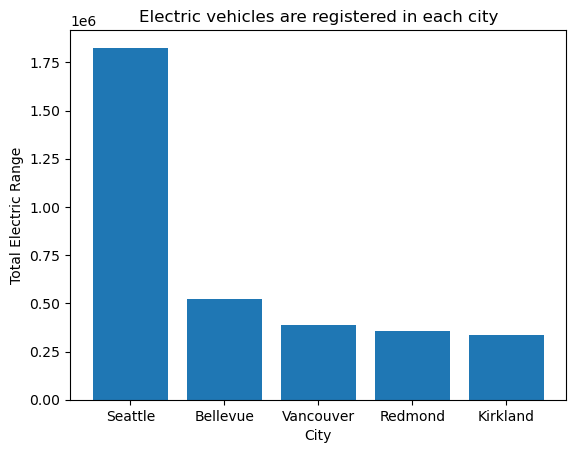

In [29]:
# How many electric vehicles are registered in each city or county?
electric = df2.groupby('City')["Electric Range"].sum().reset_index().sort_values(by='Electric Range', ascending=False).head(5)
electric
plt.bar(electric['City'], electric['Electric Range'])
plt.title('Electric vehicles are registered in each city')
plt.xlabel('City')
plt.ylabel('Total Electric Range')

# Seattle leads with the highest total electric range, followed by Bellevue and Vancouver. 
 #Other notable cities with significant EV adoption include Redmond, Kirkland, and Sammamish. 
#This suggests a strong presence of electric vehicle usage and infrastructure in major urban areas of Washington.



Text(0, 0.5, 'Count of model')

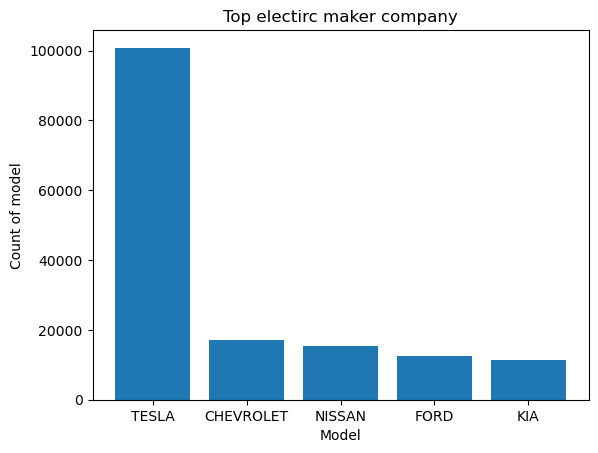

In [20]:
#What are the most popular electric vehicle makes and models?
models = df2.groupby('Make')['Model'].count().reset_index().sort_values(by='Model', ascending=False).head()
plt.bar(models['Make'], models['Model'])
plt.title('Top electirc maker company')
plt.xlabel('Model')
plt.ylabel('Count of model')

# EV Registration by Car Make

#Tesla dominates the electric vehicle landscape with over 100,000 registrations—far surpassing other manufacturers. Chevrolet and Nissan follow #distantly, while Ford and Kia also show notable adoption. This reflects Tesla's strong market presence and brand leadership in the EV sector.

Text(0, 0.5, 'sum of EV')

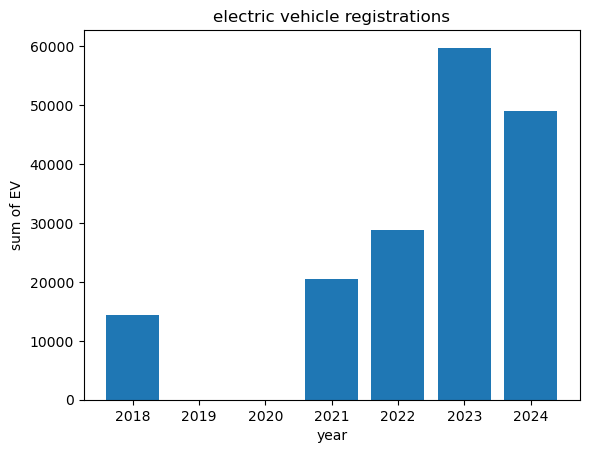

In [37]:
#Which year has the highest number of electric vehicle registrations?
registeration = df2.groupby('Model Year')['Model'].count().reset_index().sort_values(by = 'Model' , ascending=False).head()
plt.bar(registeration['Model Year'], registeration['Model'])
plt.title('electric vehicle registrations')
plt.xlabel("year")
plt.ylabel('sum of EV')

 # EV Adoption by Model Year

#Electric vehicle registrations have surged in recent years, with 2023 and 2024 models showing the highest adoption—59,769 and 48,995 respectively. #This upward trend reflects growing consumer interest, improved technology, and stronger policy support for sustainable transportation.



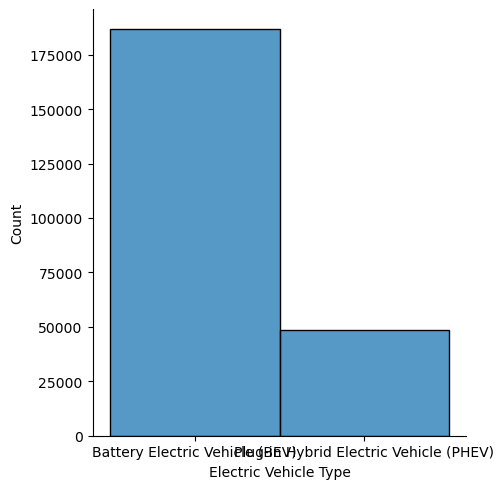

In [39]:
#the distribution of Electric Vehicle Types (BEV vs PHEV)
import seaborn as sns
sns.displot(df2, x = 'Electric Vehicle Type')

#How many vehicles are eligible for Clean Alternative Fuel Vehicle (CAFV) programs?


df2.head(1)

In [25]:
df2['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].value_counts()

Clean Alternative Fuel Vehicle (CAFV) Eligibility
Eligibility unknown as battery range has not been researched    139501
Clean Alternative Fuel Vehicle Eligible                          73111
Not eligible due to low battery range                            22543
Name: count, dtype: int64

In [26]:
clean = df2.groupby('Clean Alternative Fuel Vehicle (CAFV) Eligibility')['Electric Range'].count().reset_index()
eligible_range = clean[clean['Clean Alternative Fuel Vehicle (CAFV) Eligibility'] == 'Clean Alternative Fuel Vehicle Eligible']['Electric Range']
eligible_range

0    73111
Name: Electric Range, dtype: int64

# Trend and Distribution Questions

In [220]:
# What is the trend of EV adoption by model year
ev_trend = df2.groupby('Model Year').size().reset_index(name='Number of year')
ev_trends = ev_trend.sort_values('Model Year',ascending = False).head(8)
ev_trends

,Model Year,Number of year
19,2025,11137
18,2024,48995
17,2023,59769
16,2022,28861
15,2021,20553
14,2020,12234
13,2019,10949
12,2018,14331


# EV Adoption by Model Year

Electric vehicle adoption has shown a consistent upward trend from 2018 to 2023, peaking in 2023 with 59,769 vehicles. Although there's a slight dip in 2024 (48,995) and a projected lower number in 2025 so far (11,137), the overall growth reflects increasing consumer interest and expanding EV infrastructure over recent years.

In [29]:
# Which counties are seeing the highest growth in EV registrations?

In [30]:
df2['County'].value_counts().head(8)

County
King         118688
Snohomish     28810
Pierce        19256
Clark         14092
Thurston       8595
Kitsap         7901
Spokane        6579
Whatcom        5703
Name: count, dtype: int64

# EV Adoption by County in Washington

King County leads significantly in EV adoption with 118,688 registered vehicles — over four times more than the next highest, Snohomish County (28,810). This trend highlights King County as the primary hub for electric vehicles in the state, likely driven by stronger infrastructure, urban population density, and environmental initiatives.



<BarContainer object of 10 artists>

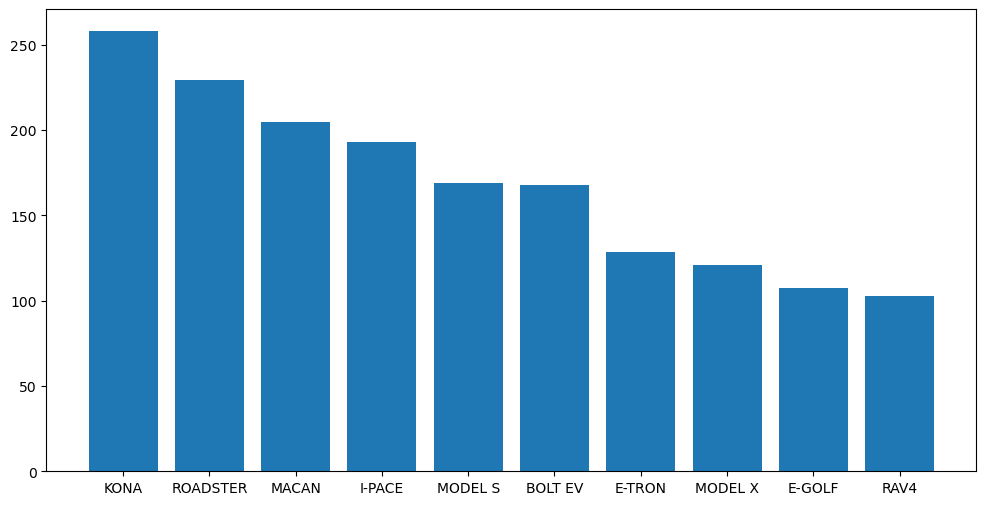

In [43]:
# What is the average electric range by vehicle make/model
Electric_range_by_vehicle = df2.groupby('Model')['Electric Range'].mean().reset_index().sort_values(by = 'Electric Range', ascending = False).head(10)
plt.figure(figsize=(12, 6))
plt.bar (Electric_range_by_vehicle['Model'], Electric_range_by_vehicle['Electric Range'])

# Top EV Models by Average Electric Range

The Hyundai KONA leads with the highest average electric range at 258 miles, followed by the Tesla Roadster (229.6 mi) and Porsche Macan (204.8 mi). This suggests that newer or premium EV models are offering extended ranges, which can greatly reduce range anxiety for users and encourage broader adoption.

In [32]:
#Which legislative districts have the highest number of electric vehicles
df2.groupby('Legislative District')['Make'].count().reset_index().sort_values(by = 'Make', ascending= False ).head(1)

,Legislative District,Make
40,41.0,14538


# Leading in EV Adoption

Legislative District 41 has the highest number of electric vehicles registered, with 14,538 units. This indicates strong EV adoption in the area—possibly driven by favorable infrastructure, incentives, and environmentally conscious residents.

# Infrastructure and Utility Analysis

Text(0.5, 1.0, 'electric utilities serve the most EVs')

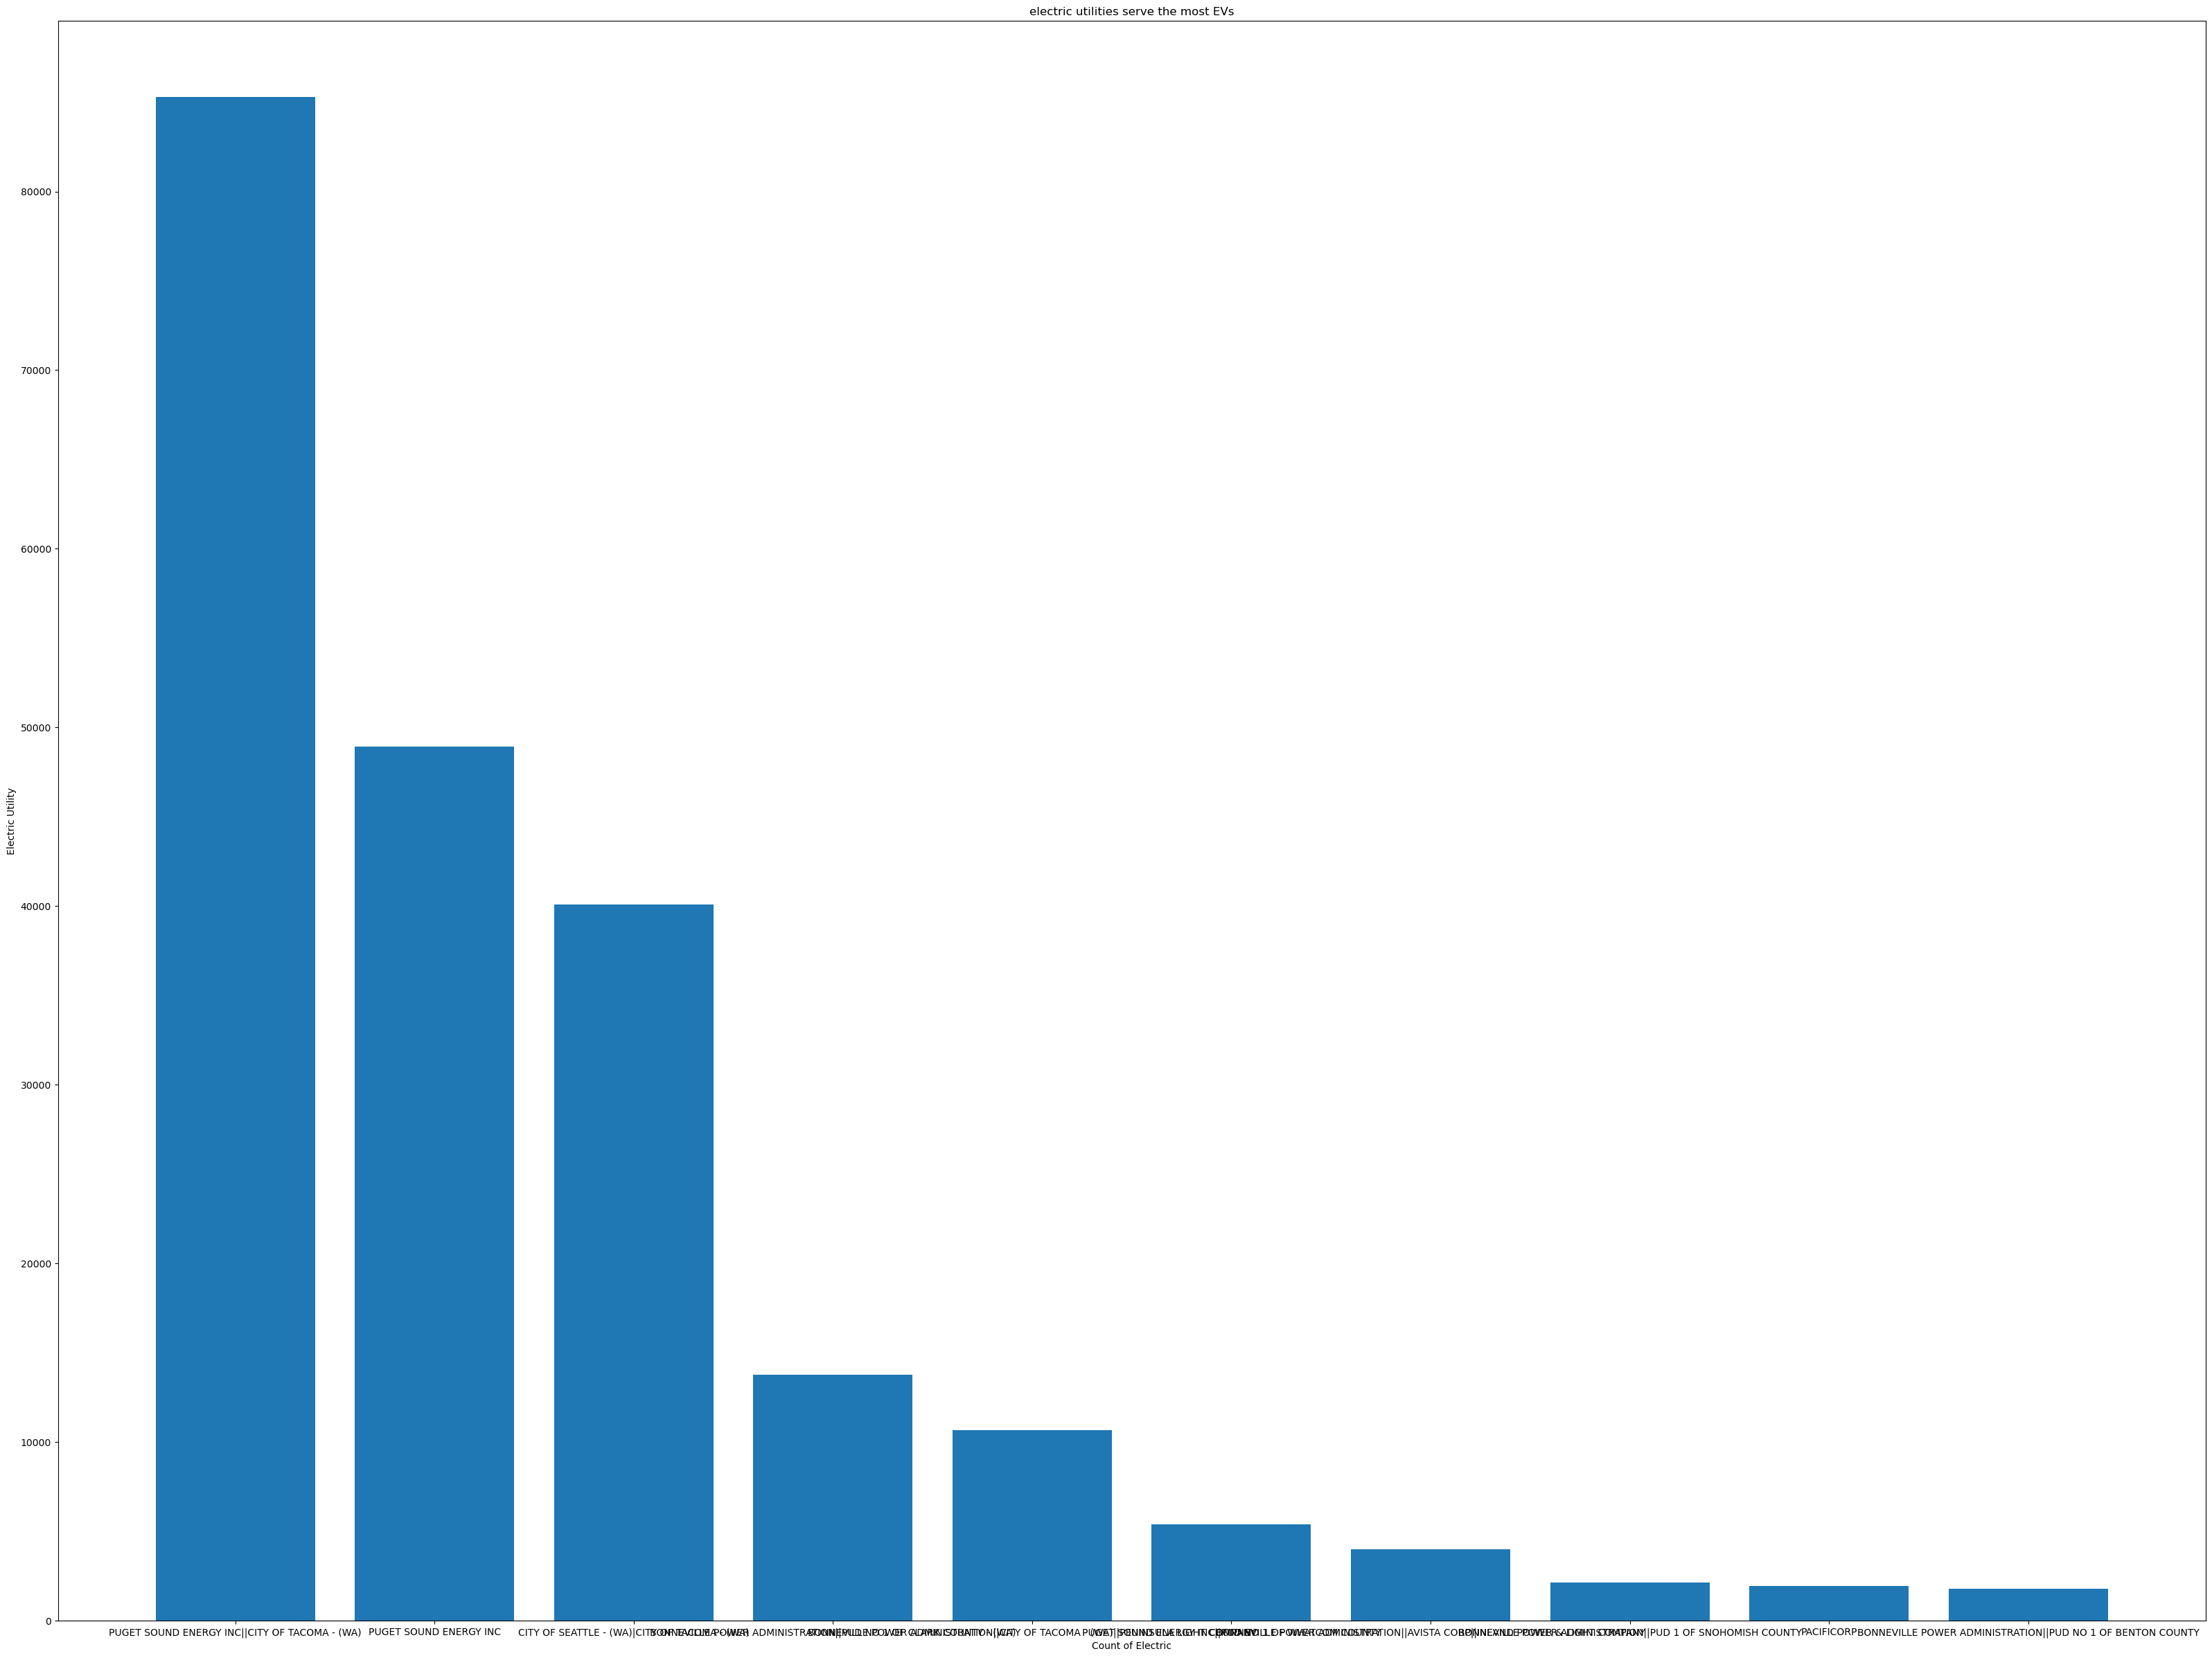

In [58]:
# Which electric utilities serve the most EVs
utility = df2['Electric Utility'].value_counts().reset_index().head(10)
utility
plt.figure(figsize=(40,30))
plt.bar(utility['Electric Utility'], utility['count'])
plt.xlabel('Count of Electric')
plt.ylabel('Electric Utility')
plt.title('electric utilities serve the most EVs')

# EV Adoption by Electric Utility Providers

Puget Sound Energy Inc, often in partnership with City of Tacoma, leads in EV adoption with over 85,000 vehicles. It’s followed by Puget Sound Energy alone (48,918) and Seattle-Tacoma utilities (40,097). This highlights the pivotal role of utility providers in supporting EV infrastructure and adoption.

# Geographic and Demographic Analysis

In [83]:
# How does EV adoption vary by electric utility providers?
df2['2020 Census Tract'].value_counts().head(10).reset_index()

,2020 Census Tract,count
0,53033028200,2647
1,53033026200,1174
2,53033009300,999
3,53033032321,994
4,53067011200,839
5,53033032220,760
6,53061052107,745
7,53033022803,743
8,53033032318,741
9,53033032215,719


# Top Census Tracts for EV Ownership

Census Tract 53033028200 leads with 2,647 electric vehicles, followed by 53033026200 (1,174) and 53033009300 (999). These high-adoption zones suggest concentrated EV use, likely driven by better infrastructure, higher income levels, or supportive local policies.

In [97]:
# Suppose 'df' contains 'Model' and 'Vehicle Location' columns
pivot_df = df2.groupby(['Model', 'Vehicle Location']).size().unstack(fill_value=0)

# Now you can find correlation between models across locations
correlation_matrix = pivot_df.corr()


<Axes: xlabel='Vehicle Location', ylabel='Vehicle Location'>

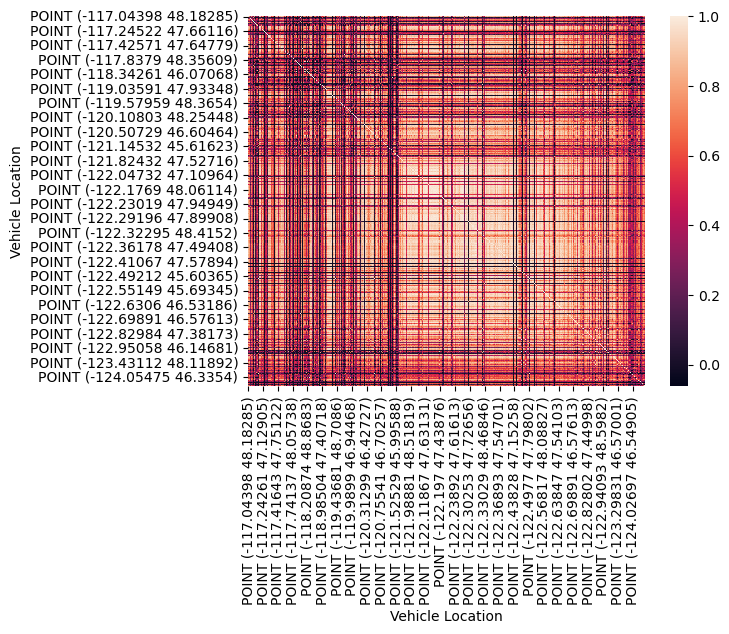

In [103]:
sns.heatmap(correlation_matrix)

# Financial and Market Analysis

In [110]:
# What is the distribution of base MSRP among different EV types or models?

Text(0.5, 1.0, 'Distribution of base MSRP among different EV types or models')

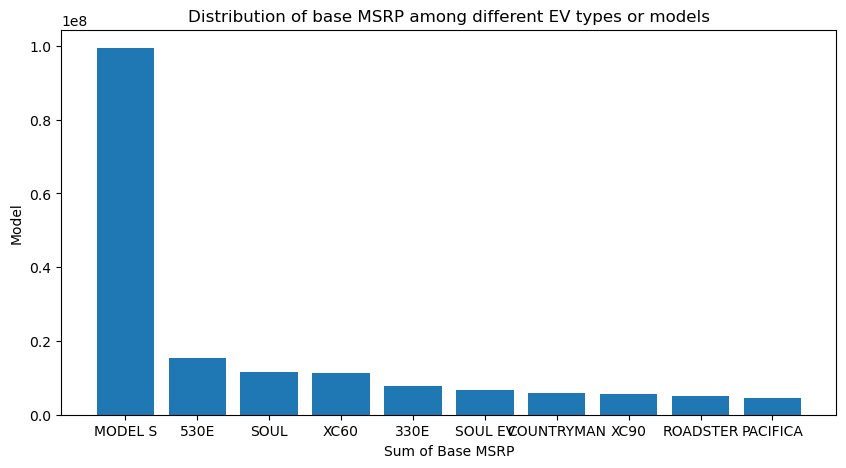

In [64]:
market = df2.groupby('Model')['Base MSRP'].sum().sort_values(ascending = False).head(10).reset_index()
plt.figure(figsize = (10,5))
plt.bar(market['Model'],market['Base MSRP'])
plt.xlabel('Sum of Base MSRP')
plt.ylabel('Model')
plt.title('Distribution of base MSRP among different EV types or models')

# Top EV Models by Base MSRP

The Tesla Model S stands out with the highest base MSRP of ₹99,406,000, indicating its premium market positioning. Other high-cost models include BMW 530E (₹15,371,400) and Kia Soul (₹11,533,950), while more accessible models like the Pacifica start at ₹4,639,420, reflecting a wide range in EV pricing to suit diverse customer segments.

Text(0.5, 1.0, 'Cities have more expensive EVs based on average MSRP')

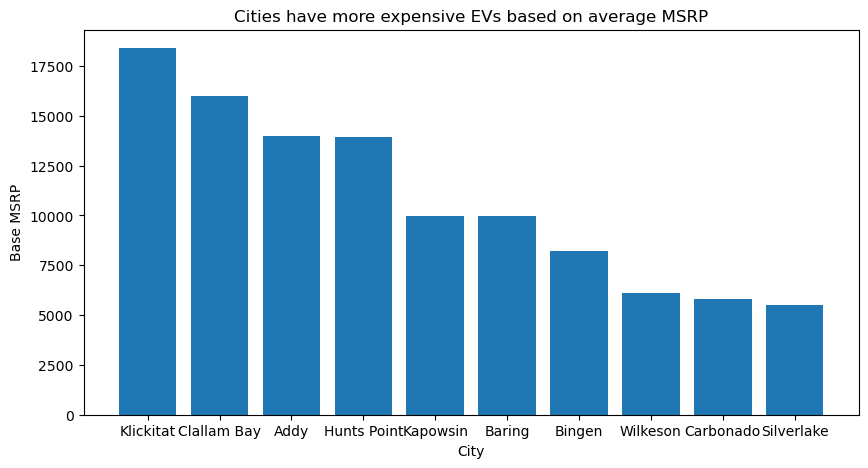

In [69]:
market = df2.groupby('City')['Base MSRP'].mean().sort_values(ascending = False).head(10).reset_index()
plt.figure(figsize=(10,5))
plt.bar(market['City'], market['Base MSRP'])
plt.xlabel('City')
plt.ylabel('Base MSRP')
plt.title('Cities have more expensive EVs based on average MSRP')

# EV Base Price Distribution by City

Cities like Klickitat and Clallam Bay show the highest average EV base MSRPs at ₹18,400 and ₹15,975 respectively, indicating a preference for higher-end models. In contrast, places like Silverlake and Carbonado feature more affordable EV options under ₹6,000, suggesting a demand for cost-effective electric vehicles in smaller or rural areas.